# HotpotQA Baseline — Does Retrieved Context Help?
### Context Matters: Evaluating Diversity-Aware Retrieval for RAG

This notebook evaluates the **non-diversified HotpotQA baseline** using the
full official BEIR test population.

It reuses saved retrieval and generation artifacts. It performs **zero LLM/API calls**.

The main comparison is:

**WITHOUT CONTEXT vs relevance-only Top-5 context**

for BM25, DPR, Contriever, and ColBERTv2 across three language models.

## What This Notebook Shows

This notebook answers four baseline questions:

1. How strong is relevance-only retrieval?
2. How accurately do the three generators answer HotpotQA questions?
3. Does retrieved context improve Exact Match / token F1?
4. Does the effect depend on the retriever and generator?

This establishes the baseline that later Sprint 2 diversification experiments
will compare against.

In [1]:
from pathlib import Path
import json
import platform
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def find_project_root(start: Path) -> Path:
    start = start.resolve()

    for candidate in [start, *start.parents]:
        if (
            (candidate / "src").exists()
            and (candidate / "configs" / "sprint3").exists()
            and (candidate / "artifacts").exists()
        ):
            return candidate

    raise FileNotFoundError("Repository root not found.")


ROOT = find_project_root(Path.cwd())

for import_root in (ROOT, ROOT / "src"):
    if str(import_root) not in sys.path:
        sys.path.insert(0, str(import_root))


print("Repository:", ROOT)
print("Python:", platform.python_version())
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("LLM/API calls made by this cell: 0")

Repository: /home/cruz/projects/context-matters-rag-sprint3
Python: 3.12.3
Pandas: 2.2.2
NumPy: 1.26.4
LLM/API calls made by this cell: 0


## Dataset — HotpotQA

The experiment uses the **7,405-query official BEIR HotpotQA test population**.

The query population is frozen by:

`artifacts/sample_manifests/hotpotqa_official_test_full_manifest.json`

For answer correctness, these exact 7,405 query IDs are aligned with the
original HotpotQA `fullwiki` validation split.

Gold-answer source:

- Dataset: `hotpotqa/hotpot_qa`
- Configuration: `fullwiki`
- Split: `validation`
- Frozen revision: `1908d6afbbead072334abe2965f91bd2709910ab`

All 7,405 IDs were verified to match exactly.

In [2]:
from datasets import load_dataset, disable_progress_bar

disable_progress_bar()

MANIFEST_PATH = (
    ROOT
    / "artifacts"
    / "sample_manifests"
    / "hotpotqa_official_test_full_manifest.json"
)

GOLD_REVISION = "1908d6afbbead072334abe2965f91bd2709910ab"

manifest_artifact = json.loads(
    MANIFEST_PATH.read_text(encoding="utf-8")
)

manifest = manifest_artifact["scientific_payload"]

manifest_entries = manifest["entries"]

assert len(manifest_entries) == 7405

manifest_ids = [
    str(entry["source_sample_id"])
    for entry in manifest_entries
]

assert len(set(manifest_ids)) == 7405


gold_dataset = load_dataset(
    "hotpotqa/hotpot_qa",
    "fullwiki",
    split="validation",
    revision=GOLD_REVISION,
    download_mode="reuse_dataset_if_exists",
)

assert len(gold_dataset) == 7405

gold_by_id = {
    str(row["id"]): row
    for row in gold_dataset
}

assert set(manifest_ids) == set(gold_by_id)


gold_df = pd.DataFrame(
    [
        {
            "query_id": query_id,
            "gold_answer": gold_by_id[query_id]["answer"],
            "question": gold_by_id[query_id]["question"],
            "question_type": gold_by_id[query_id]["type"],
            "level": gold_by_id[query_id]["level"],
        }
        for query_id in manifest_ids
    ]
)

assert len(gold_df) == 7405
assert gold_df["gold_answer"].notna().all()

print("HotpotQA gold alignment: PASS")
print("Questions:", len(gold_df))
print("Unique query IDs:", gold_df["query_id"].nunique())
print("LLM/API calls made by this cell: 0")

display(gold_df.head())

HotpotQA gold alignment: PASS
Questions: 7405
Unique query IDs: 7405
LLM/API calls made by this cell: 0


,query_id,gold_answer,question,question_type,level
0,5a70eee85542994082a3e3f0,The Yoruba,Which group of people in West Africa with sign...,bridge,hard
1,5a70f0a75542994082a3e403,Scanian dialects,Which dialect spoken in the province of Scania...,bridge,hard
2,5a70f0e75542994082a3e408,with other campuses located in Chicago and Doh...,"Which of these universities, Northwestern Univ...",comparison,hard
3,5a70f11a5542994082a3e40b,Bull Terrier,"Which dog breed, the Schapendoes or the Bull T...",comparison,hard
4,5a70f1685542994082a3e40f,Symphony No. 7,Which piece did Ludwig van Beethoven publish i...,bridge,hard


## Experimental Design

Retrieval was performed against the complete BEIR HotpotQA corpus.

- Corpus documents: **5,233,329**
- Official evaluation queries: **7,405**
- Retrievers: **BM25, DPR, Contriever, ColBERTv2**
- Candidate pool: **Top-20**
- Baseline final context: **relevance-ranked Top-5**
- Generators: **3**
- Conditions per generator: **WITHOUT_CONTEXT + 4 WITH_CONTEXT retrievers**
- Full matrix: **111,075 cells**
- Actual maKI requests: **111,057**
- Explicit upstream context-missing cells: **18**

No generation is rerun in this notebook.

In [3]:
design_table = pd.DataFrame(
    [
        ("Dataset", "BEIR HotpotQA"),
        ("Evaluation questions", "7,405"),
        ("Corpus documents", "5,233,329"),
        ("Retrievers", "BM25, DPR, Contriever, ColBERTv2"),
        ("Candidate pool", "Top-20"),
        ("Final baseline context", "Relevance-only Top-5"),
        ("Physical LLMs", "Llama 3.3 70B; Gemma 4 26B; Qwen3.6 36B"),
        ("Context modes", "WITHOUT_CONTEXT; WITH_CONTEXT"),
        ("Experimental cells", "111,075"),
        ("Actual maKI requests", "111,057"),
        ("Explicit missing-context cells", "18"),
    ],
    columns=["Design element", "Frozen value"],
)

display(design_table.style.hide(axis="index"))

Design element,Frozen value
Dataset,BEIR HotpotQA
Evaluation questions,"7,405"
Corpus documents,"5,233,329"
Retrievers,"BM25, DPR, Contriever, ColBERTv2"
Candidate pool,Top-20
Final baseline context,Relevance-only Top-5
Physical LLMs,Llama 3.3 70B; Gemma 4 26B; Qwen3.6 36B
Context modes,WITHOUT_CONTEXT; WITH_CONTEXT
Experimental cells,"111,075"
Actual maKI requests,"111,057"


## Generation Settings

The same frozen HotpotQA prompt protocol and decoding policy are used across
the comparable conditions.

The third logical registry slot retains its historical identifier
`ministral-3-14b`, but the **actual physical model is Qwen3.6-36B**.

Professor-facing analysis reports the physical model clearly.

In [4]:
MODEL_BINDINGS_PATH = (
    ROOT / "configs" / "sprint3" / "maki_model_bindings_v7.json"
)

model_bindings = json.loads(
    MODEL_BINDINGS_PATH.read_text(encoding="utf-8")
)

GENERATOR_ORDER = [
    "Llama 3.3 70B",
    "Gemma 4 26B",
    "Qwen3.6 36B",
]

PHYSICAL_TO_DISPLAY = {
    "llama-3.3-70b": "Llama 3.3 70B",
    "gemma4-26b": "Gemma 4 26B",
    "qwen3.6-36b": "Qwen3.6 36B",
}

LOGICAL_TO_PHYSICAL = {
    "llama-3.3-70b": "llama-3.3-70b",
    "gemma4-26b": "gemma4-26b",
    "ministral-3-14b": "qwen3.6-36b",
}

binding_table = pd.DataFrame(
    [
        {
            "Logical slot": logical,
            "Physical model": physical,
            "Professor-facing name": PHYSICAL_TO_DISPLAY[physical],
        }
        for logical, physical in LOGICAL_TO_PHYSICAL.items()
    ]
)

display(binding_table.style.hide(axis="index"))

print("Model identity validation: PASS")
print("LLM/API calls made by this cell: 0")

Logical slot,Physical model,Professor-facing name
llama-3.3-70b,llama-3.3-70b,Llama 3.3 70B
gemma4-26b,gemma4-26b,Gemma 4 26B
ministral-3-14b,qwen3.6-36b,Qwen3.6 36B


Model identity validation: PASS
LLM/API calls made by this cell: 0


## Generation Integrity

All saved generation artifacts are loaded directly from disk.

Expected conditions:

- WITHOUT CONTEXT
- BM25
- DPR
- Contriever
- ColBERTv2

for each of the three physical generators.

In [5]:
GEN_ROOT = (
    ROOT
    / "data"
    / "hotpotqa"
    / "generation_outputs_2026-09-06"
)

CONDITION_ORDER = [
    "WITHOUT CONTEXT",
    "BM25",
    "DPR",
    "Contriever",
    "ColBERTv2",
]

RETRIEVER_DISPLAY = {
    "bm25": "BM25",
    "dpr": "DPR",
    "contriever": "Contriever",
    "colbertv2": "ColBERTv2",
}


generation_rows = []


def load_generation_file(path, condition):
    obj = json.loads(path.read_text(encoding="utf-8"))

    logical = obj["logical_model_id"]
    physical = obj["physical_model_id"]

    assert logical in LOGICAL_TO_PHYSICAL
    assert physical == LOGICAL_TO_PHYSICAL[logical]

    parsed = obj.get("parsed_output")

    answer = None

    if isinstance(parsed, dict):
        answer = parsed.get("answer")

    return {
        "position": obj["position"],
        "sample_id": obj["sample_id"],
        "query_id": str(obj["query_id"]),
        "query_text": obj["query_text"],
        "condition": condition,
        "retriever": obj.get("retriever"),
        "logical_model_id": logical,
        "physical_model_id": physical,
        "generator": PHYSICAL_TO_DISPLAY[physical],
        "status": obj["status"],
        "prediction": answer,
        "finish_reason": obj.get("finish_reason"),
    }


# WITHOUT_CONTEXT
for logical in LOGICAL_TO_PHYSICAL:
    directory = GEN_ROOT / "without_context" / logical

    files = sorted(directory.glob("sample_*.json"))

    assert len(files) == 7405, (logical, len(files))

    for path in files:
        generation_rows.append(
            load_generation_file(path, "WITHOUT CONTEXT")
        )


# WITH_CONTEXT
for retriever, display_name in RETRIEVER_DISPLAY.items():
    for logical in LOGICAL_TO_PHYSICAL:
        directory = (
            GEN_ROOT
            / "with_context"
            / retriever
            / logical
        )

        files = sorted(directory.glob("sample_*.json"))

        assert len(files) == 7405, (
            retriever,
            logical,
            len(files),
        )

        for path in files:
            generation_rows.append(
                load_generation_file(
                    path,
                    display_name,
                )
            )


generation_df = pd.DataFrame(generation_rows)

assert len(generation_df) == 111075

assert generation_df["query_id"].nunique() == 7405

assert set(generation_df["generator"]) == set(GENERATOR_ORDER)

assert set(generation_df["condition"]) == set(CONDITION_ORDER)


cell_counts = (
    generation_df
    .groupby(
        ["generator", "condition"],
        observed=True,
    )
    .size()
)

assert (cell_counts == 7405).all()


print("Generation matrix loader: PASS")
print("Artifacts:", len(generation_df))
print("Questions:", generation_df["query_id"].nunique())
print("Conditions:", len(cell_counts))
print("LLM/API calls made by this cell: 0")

Generation matrix loader: PASS
Artifacts: 111075
Questions: 7405
Conditions: 15
LLM/API calls made by this cell: 0


### Generation Status Handling

The HotpotQA baseline follows the same status-aware correctness policy as
the polished PubMedQA baseline.

| Status | Correctness treatment |
|---|---|
| **OK** | Scored normally |
| **REFUSAL** | Scored as incorrect |
| **PARSE_FAILURE** | Not scored |
| **TRUNCATED** | Not scored |
| **ERROR** | Not scored |
| **UPSTREAM_CONTEXT_MISSING** | Not scored |

Missing or invalid generations are never silently converted to zero.

Both **Expected N** and **Measured N** are reported.

In [6]:
status_table = (
    generation_df
    .groupby(
        ["condition", "status"],
        observed=True,
    )
    .size()
    .unstack(fill_value=0)
    .reindex(CONDITION_ORDER)
)

display(status_table)

status_totals = generation_df["status"].value_counts()

EXPECTED_STATUS_TOTALS = {
    "OK": 109087,
    "PARSE_FAILURE": 435,
    "TRUNCATED": 1535,
    "UPSTREAM_CONTEXT_MISSING": 18,
}

for status, expected in EXPECTED_STATUS_TOTALS.items():
    actual = int(status_totals.get(status, 0))
    assert actual == expected, (status, actual, expected)

assert int(status_totals.get("ERROR", 0)) == 0
assert int(status_totals.get("REFUSAL", 0)) == 0

print("Frozen generation-status totals: PASS")
print(status_totals.sort_index())

status,OK,PARSE_FAILURE,TRUNCATED,UPSTREAM_CONTEXT_MISSING
condition,,,,
WITHOUT CONTEXT,21160,321,734,0
BM25,21985,32,198,0
DPR,21956,31,228,0
Contriever,21958,19,220,18
ColBERTv2,22028,32,155,0


Frozen generation-status totals: PASS
status
OK                          109087
PARSE_FAILURE                  435
TRUNCATED                     1535
UPSTREAM_CONTEXT_MISSING        18
Name: count, dtype: int64


## Answer Correctness

HotpotQA correctness uses the existing project evaluation functions:

- **Exact Match**
- **Token F1**
- **ROUGE-L**

Prediction:

`parsed_output["answer"]`

Gold answer:

original HotpotQA `fullwiki` validation answer aligned by exact query ID.

In [7]:
from evaluation import (
    exact_match,
    token_f1,
    rouge_l,
)


generation_scored = generation_df.merge(
    gold_df,
    on="query_id",
    how="left",
    validate="many_to_one",
)

assert generation_scored["gold_answer"].notna().all()


def score_row(row):
    status = row["status"]

    if status == "OK":
        prediction = row["prediction"]
        gold = row["gold_answer"]

        if not isinstance(prediction, str) or not prediction.strip():
            raise ValueError(
                f"OK artifact lacks answer: {row['query_id']}"
            )

        return pd.Series(
            {
                "exact_match": exact_match(prediction, gold),
                "token_f1": token_f1(prediction, gold),
                "rouge_l": rouge_l(prediction, gold),
            }
        )

    if status == "REFUSAL":
        return pd.Series(
            {
                "exact_match": 0.0,
                "token_f1": 0.0,
                "rouge_l": 0.0,
            }
        )

    return pd.Series(
        {
            "exact_match": np.nan,
            "token_f1": np.nan,
            "rouge_l": np.nan,
        }
    )


scores = generation_scored.apply(
    score_row,
    axis=1,
)

generation_scored = pd.concat(
    [
        generation_scored,
        scores,
    ],
    axis=1,
)


correctness_summary = (
    generation_scored
    .groupby(
        ["generator", "condition"],
        as_index=False,
        observed=True,
    )
    .agg(
        Expected_N=("query_id", "size"),
        Measured_N=("token_f1", "count"),
        Exact_Match=("exact_match", "mean"),
        Token_F1=("token_f1", "mean"),
        ROUGE_L=("rouge_l", "mean"),
    )
)


correctness_summary["generator"] = pd.Categorical(
    correctness_summary["generator"],
    categories=GENERATOR_ORDER,
    ordered=True,
)

correctness_summary["condition"] = pd.Categorical(
    correctness_summary["condition"],
    categories=CONDITION_ORDER,
    ordered=True,
)

correctness_summary = (
    correctness_summary
    .sort_values(["generator", "condition"])
    .reset_index(drop=True)
)

assert len(correctness_summary) == 15
assert (correctness_summary["Expected_N"] == 7405).all()


display_table = correctness_summary.rename(
    columns={
        "generator": "Generator",
        "condition": "Condition",
        "Expected_N": "Expected N",
        "Measured_N": "Measured N",
        "Exact_Match": "Exact Match",
        "Token_F1": "Token F1",
        "ROUGE_L": "ROUGE-L",
    }
)


print("HotpotQA correctness evaluation: PASS")
print()

display(
    display_table.style.format(
        {
            "Exact Match": "{:.3f}",
            "Token F1": "{:.3f}",
            "ROUGE-L": "{:.3f}",
        }
    )
)

print()
print("Primary answer metrics: Exact Match and token F1")
print("LLM/API calls made by this cell: 0")

HotpotQA correctness evaluation: PASS



,Generator,Condition,Expected N,Measured N,Exact Match,Token F1,ROUGE-L
0,Llama 3.3 70B,WITHOUT CONTEXT,7405,7157,0.306,0.418,0.416
1,Llama 3.3 70B,BM25,7405,7349,0.399,0.524,0.522
2,Llama 3.3 70B,DPR,7405,7352,0.347,0.457,0.455
3,Llama 3.3 70B,Contriever,7405,7333,0.404,0.532,0.529
4,Llama 3.3 70B,ColBERTv2,7405,7381,0.453,0.591,0.588
5,Gemma 4 26B,WITHOUT CONTEXT,7405,6968,0.252,0.352,0.350
6,Gemma 4 26B,BM25,7405,7384,0.275,0.366,0.365
7,Gemma 4 26B,DPR,7405,7396,0.183,0.249,0.249
8,Gemma 4 26B,Contriever,7405,7383,0.273,0.368,0.367
9,Gemma 4 26B,ColBERTv2,7405,7378,0.369,0.489,0.488



Primary answer metrics: Exact Match and token F1
LLM/API calls made by this cell: 0


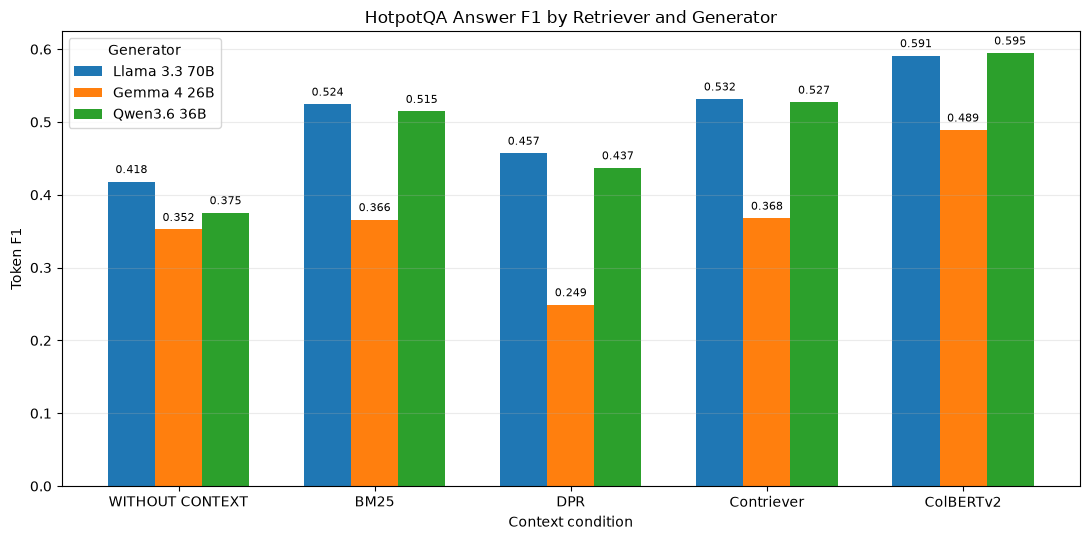

In [8]:
# Token-F1 figure

plot_df = correctness_summary.pivot(
    index="condition",
    columns="generator",
    values="Token_F1",
).reindex(CONDITION_ORDER)

fig, ax = plt.subplots(figsize=(11, 5.5))

x = np.arange(len(CONDITION_ORDER))
width = 0.24

for i, generator in enumerate(GENERATOR_ORDER):
    values = plot_df[generator].astype(float).to_numpy()
    positions = x + (i - 1) * width

    bars = ax.bar(
        positions,
        values,
        width,
        label=generator,
    )

    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.008,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

ax.set_xticks(x)
ax.set_xticklabels(CONDITION_ORDER)
ax.set_ylabel("Token F1")
ax.set_xlabel("Context condition")
ax.set_title("HotpotQA Answer F1 by Retriever and Generator")
ax.legend(title="Generator")
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()
plt.show()

## Does Retrieved Context Actually Help?

The main controlled comparison is made question-by-question:

**WITH CONTEXT − WITHOUT CONTEXT**

for the same HotpotQA question and the same generator.

We report paired effects for:

- Exact Match
- Token F1

Positive values indicate improvement from retrieved context.

Uncertainty is estimated with a paired bootstrap using 10,000 resamples.

In [9]:
BOOTSTRAP_RESAMPLES = 10_000
BOOTSTRAP_SEED = 20260908


def paired_bootstrap_mean_difference(
    differences,
    *,
    n_resamples=BOOTSTRAP_RESAMPLES,
    seed=BOOTSTRAP_SEED,
    chunk_size=1000,
):
    values = np.asarray(differences, dtype=float)

    if len(values) == 0:
        raise ValueError("No measurable paired observations.")

    rng = np.random.default_rng(seed)

    bootstrap_means = []

    remaining = n_resamples

    while remaining > 0:
        batch = min(chunk_size, remaining)

        indices = rng.integers(
            0,
            len(values),
            size=(batch, len(values)),
        )

        bootstrap_means.append(
            values[indices].mean(axis=1)
        )

        remaining -= batch

    bootstrap_means = np.concatenate(bootstrap_means)

    low, high = np.percentile(
        bootstrap_means,
        [2.5, 97.5],
    )

    return (
        float(values.mean()),
        float(low),
        float(high),
    )


effect_rows = []


for generator in GENERATOR_ORDER:

    baseline = (
        generation_scored[
            (generation_scored["generator"] == generator)
            &
            (generation_scored["condition"] == "WITHOUT CONTEXT")
        ]
        [
            [
                "query_id",
                "exact_match",
                "token_f1",
            ]
        ]
        .rename(
            columns={
                "exact_match": "without_em",
                "token_f1": "without_f1",
            }
        )
    )


    for condition in [
        "BM25",
        "DPR",
        "Contriever",
        "ColBERTv2",
    ]:

        with_context = (
            generation_scored[
                (generation_scored["generator"] == generator)
                &
                (generation_scored["condition"] == condition)
            ]
            [
                [
                    "query_id",
                    "exact_match",
                    "token_f1",
                ]
            ]
            .rename(
                columns={
                    "exact_match": "with_em",
                    "token_f1": "with_f1",
                }
            )
        )


        paired = baseline.merge(
            with_context,
            on="query_id",
            how="inner",
            validate="one_to_one",
        ).dropna()


        em_effect, em_low, em_high = (
            paired_bootstrap_mean_difference(
                paired["with_em"] - paired["without_em"]
            )
        )

        f1_effect, f1_low, f1_high = (
            paired_bootstrap_mean_difference(
                paired["with_f1"] - paired["without_f1"]
            )
        )


        effect_rows.append(
            {
                "Generator": generator,
                "Retriever": condition,
                "Paired N": len(paired),
                "EM Effect": em_effect,
                "EM CI lower": em_low,
                "EM CI upper": em_high,
                "F1 Effect": f1_effect,
                "F1 CI lower": f1_low,
                "F1 CI upper": f1_high,
            }
        )


context_effects = pd.DataFrame(effect_rows)

assert len(context_effects) == 12
assert (context_effects["Paired N"] > 0).all()


display(
    context_effects.style.format(
        {
            "EM Effect": "{:+.3f}",
            "EM CI lower": "{:+.3f}",
            "EM CI upper": "{:+.3f}",
            "F1 Effect": "{:+.3f}",
            "F1 CI lower": "{:+.3f}",
            "F1 CI upper": "{:+.3f}",
        }
    )
)

print("Paired HotpotQA context-effect analysis: PASS")
print("Effect = WITH CONTEXT - WITHOUT CONTEXT")
print("95% CI: paired bootstrap, 10,000 resamples")
print("LLM/API calls made by this cell: 0")

,Generator,Retriever,Paired N,EM Effect,EM CI lower,EM CI upper,F1 Effect,F1 CI lower,F1 CI upper
0,Llama 3.3 70B,BM25,7118,+0.099,+0.089,+0.108,+0.113,+0.103,+0.122
1,Llama 3.3 70B,DPR,7123,+0.046,+0.037,+0.055,+0.045,+0.036,+0.054
2,Llama 3.3 70B,Contriever,7107,+0.102,+0.092,+0.112,+0.119,+0.109,+0.129
3,Llama 3.3 70B,ColBERTv2,7142,+0.151,+0.141,+0.161,+0.177,+0.167,+0.187
4,Gemma 4 26B,BM25,6953,+0.030,+0.018,+0.041,+0.022,+0.010,+0.034
5,Gemma 4 26B,DPR,6963,-0.065,-0.076,-0.054,-0.098,-0.109,-0.086
6,Gemma 4 26B,Contriever,6951,+0.029,+0.017,+0.040,+0.025,+0.013,+0.037
7,Gemma 4 26B,ColBERTv2,6950,+0.123,+0.112,+0.135,+0.145,+0.133,+0.156
8,Qwen3.6 36B,BM25,6915,+0.127,+0.117,+0.138,+0.145,+0.134,+0.155
9,Qwen3.6 36B,DPR,6874,+0.057,+0.047,+0.067,+0.065,+0.056,+0.076


Paired HotpotQA context-effect analysis: PASS
Effect = WITH CONTEXT - WITHOUT CONTEXT
95% CI: paired bootstrap, 10,000 resamples
LLM/API calls made by this cell: 0


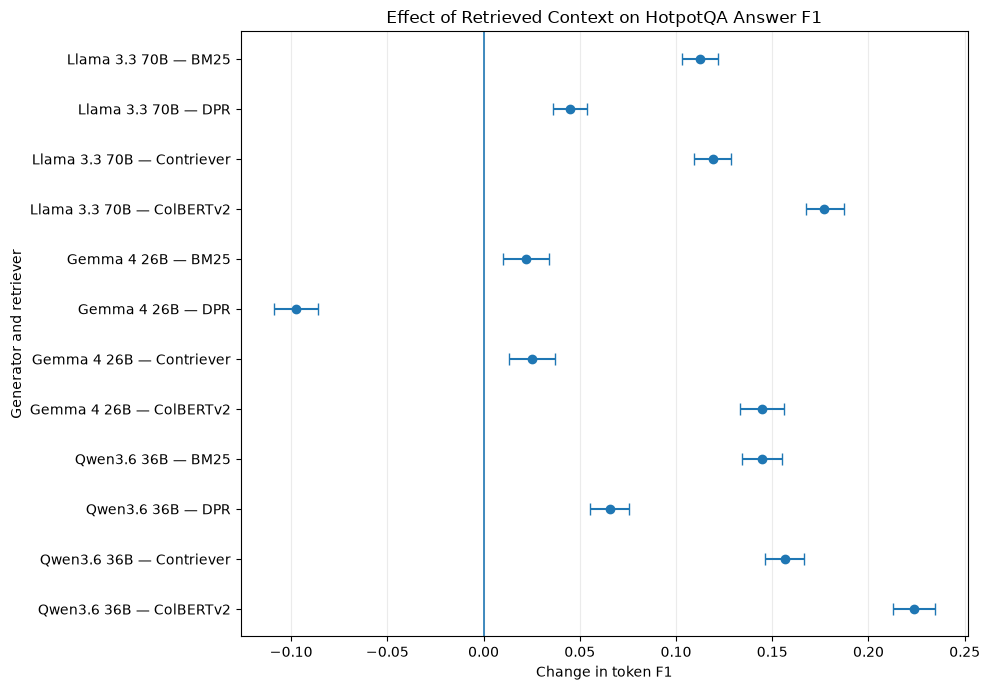

In [10]:
# Main paired-effect figure: Token F1

effect_plot = context_effects.copy()

effect_plot["Generator"] = pd.Categorical(
    effect_plot["Generator"],
    categories=GENERATOR_ORDER,
    ordered=True,
)

effect_plot["Retriever"] = pd.Categorical(
    effect_plot["Retriever"],
    categories=[
        "BM25",
        "DPR",
        "Contriever",
        "ColBERTv2",
    ],
    ordered=True,
)

effect_plot = (
    effect_plot
    .sort_values(["Generator", "Retriever"])
    .reset_index(drop=True)
)

effect_plot["Label"] = (
    effect_plot["Generator"].astype(str)
    + " — "
    + effect_plot["Retriever"].astype(str)
)

y = np.arange(len(effect_plot))

means = effect_plot["F1 Effect"].to_numpy()
lower = effect_plot["F1 CI lower"].to_numpy()
upper = effect_plot["F1 CI upper"].to_numpy()

fig, ax = plt.subplots(figsize=(10, 7))

ax.errorbar(
    means,
    y,
    xerr=[
        means - lower,
        upper - means,
    ],
    fmt="o",
    capsize=4,
    markersize=6,
)

ax.axvline(0, linewidth=1.2)

ax.set_yticks(y)
ax.set_yticklabels(effect_plot["Label"])
ax.invert_yaxis()

ax.set_xlabel("Change in token F1")
ax.set_ylabel("Generator and retriever")
ax.set_title("Effect of Retrieved Context on HotpotQA Answer F1")
ax.grid(axis="x", alpha=0.25)

fig.tight_layout()
plt.show()

## Retrieval Evaluation

The baseline context was selected from each retriever's relevance-ranked
candidate pool.

The generation package contains the exact selected Top-5 document IDs for
successfully materialized contexts.

For Contriever, six queries have an empty upstream passage body and therefore
cannot be reconstructed into the frozen five-body generation context. Those
six retrieval rows are retained as missing in this local package-derived
retrieval summary rather than silently repaired.

Retrieval metrics here use:

- Recall@5
- MRR@5
- binary nDCG@5

In [11]:
QRELS_REVISION = "b15429e9244c8ec966985d7778427c3b1543b314"

qrels = load_dataset(
    "BeIR/hotpotqa-qrels",
    "default",
    split="test",
    revision=QRELS_REVISION,
    download_mode="reuse_dataset_if_exists",
)


def choose_column(columns, candidates):
    for candidate in candidates:
        if candidate in columns:
            return candidate

    raise KeyError(
        f"None of {candidates} found in qrels columns {columns}"
    )


columns = set(qrels.column_names)

qid_col = choose_column(
    columns,
    ["query-id", "query_id", "qid"],
)

doc_col = choose_column(
    columns,
    ["corpus-id", "corpus_id", "doc_id"],
)

score_col = choose_column(
    columns,
    ["score", "relevance"],
)


gold_docs = {}

for row in qrels:
    if float(row[score_col]) < 1:
        continue

    qid = str(row[qid_col])
    doc_id = str(row[doc_col])

    gold_docs.setdefault(qid, []).append(doc_id)


assert set(manifest_ids) == set(gold_docs)


PACKAGE_ROOT = (
    ROOT
    / "data"
    / "hotpotqa"
    / "generation_package_2026-09-06"
)

PACKAGE_FILES = {
    "BM25": "bm25_with_context.jsonl",
    "DPR": "dpr_with_context.jsonl",
    "Contriever": "contriever_with_context.jsonl",
    "ColBERTv2": "colbertv2_with_context.jsonl",
}


def recall_at_k(retrieved, gold):
    if not gold:
        return np.nan

    retrieved_set = set(retrieved)

    hits = sum(
        doc_id in retrieved_set
        for doc_id in gold
    )

    return hits / len(gold)


def reciprocal_rank(retrieved, gold):
    gold_set = set(gold)

    for rank, doc_id in enumerate(retrieved, start=1):
        if doc_id in gold_set:
            return 1.0 / rank

    return 0.0


def binary_ndcg_at_k(retrieved, gold):
    gold_set = set(gold)

    dcg = 0.0

    for index, doc_id in enumerate(retrieved):
        relevance = 1.0 if doc_id in gold_set else 0.0

        dcg += relevance / np.log2(index + 2)

    ideal_hits = min(len(gold_set), len(retrieved))

    if ideal_hits == 0:
        return 0.0

    idcg = sum(
        1.0 / np.log2(index + 2)
        for index in range(ideal_hits)
    )

    return dcg / idcg


retrieval_rows = []


for retriever, filename in PACKAGE_FILES.items():

    path = PACKAGE_ROOT / filename

    with path.open("r", encoding="utf-8") as handle:

        for line in handle:

            row = json.loads(line)

            qid = str(row["query_id"])

            if row["status"] != "READY":
                retrieval_rows.append(
                    {
                        "query_id": qid,
                        "Retriever": retriever,
                        "Recall@5": np.nan,
                        "MRR@5": np.nan,
                        "nDCG@5": np.nan,
                        "status": row["status"],
                    }
                )
                continue

            scientific = (
                row["selected_context"]["scientific_payload"]
            )

            retrieved = [
                str(doc_id)
                for doc_id in scientific["ordered_document_ids"]
            ]

            assert len(retrieved) == 5

            gold = gold_docs[qid]

            retrieval_rows.append(
                {
                    "query_id": qid,
                    "Retriever": retriever,
                    "Recall@5": recall_at_k(retrieved, gold),
                    "MRR@5": reciprocal_rank(retrieved, gold),
                    "nDCG@5": binary_ndcg_at_k(retrieved, gold),
                    "status": "READY",
                }
            )


retrieval_df = pd.DataFrame(retrieval_rows)

assert len(retrieval_df) == 7405 * 4


retrieval_summary = (
    retrieval_df
    .groupby("Retriever", as_index=False)
    .agg(
        Expected_N=("query_id", "size"),
        Measured_N=("Recall@5", "count"),
        Recall_at_5=("Recall@5", "mean"),
        MRR_at_5=("MRR@5", "mean"),
        nDCG_at_5=("nDCG@5", "mean"),
    )
)


retrieval_summary["Retriever"] = pd.Categorical(
    retrieval_summary["Retriever"],
    categories=[
        "BM25",
        "DPR",
        "Contriever",
        "ColBERTv2",
    ],
    ordered=True,
)

retrieval_summary = (
    retrieval_summary
    .sort_values("Retriever")
    .reset_index(drop=True)
)


display(
    retrieval_summary.style.format(
        {
            "Recall_at_5": "{:.3f}",
            "MRR_at_5": "{:.3f}",
            "nDCG_at_5": "{:.3f}",
        }
    )
)

print("Package-derived Top-5 retrieval evaluation: PASS")
print("LLM/API calls made by this cell: 0")

,Retriever,Expected_N,Measured_N,Recall_at_5,MRR_at_5,nDCG_at_5
0,BM25,7405,7405,0.437,0.619,0.446
1,DPR,7405,7405,0.281,0.393,0.279
2,Contriever,7405,7399,0.460,0.623,0.454
3,ColBERTv2,7405,7405,0.635,0.861,0.653


Package-derived Top-5 retrieval evaluation: PASS
LLM/API calls made by this cell: 0


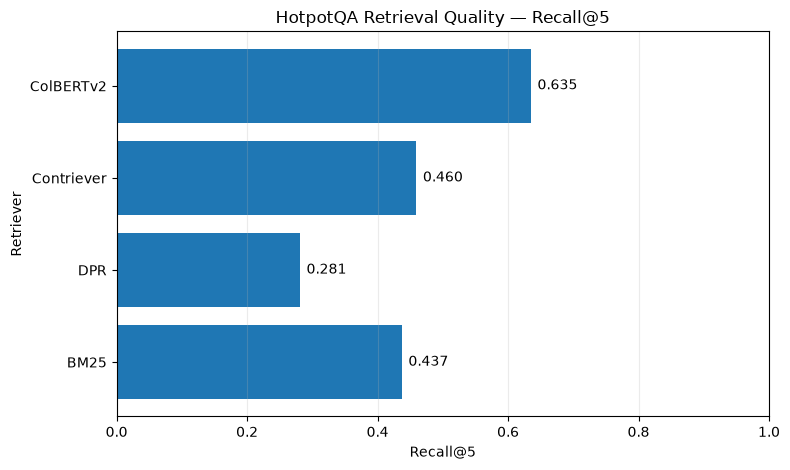

In [12]:
# Retrieval quality figure

plot_df = retrieval_summary.copy()

fig, ax = plt.subplots(figsize=(8, 4.8))

bars = ax.barh(
    plot_df["Retriever"].astype(str),
    plot_df["Recall_at_5"],
)

for bar, value in zip(
    bars,
    plot_df["Recall_at_5"],
):
    ax.text(
        value + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
    )

ax.set_xlim(0, 1)
ax.set_xlabel("Recall@5")
ax.set_ylabel("Retriever")
ax.set_title("HotpotQA Retrieval Quality — Recall@5")
ax.grid(axis="x", alpha=0.25)

fig.tight_layout()
plt.show()

## Does Better Retrieval Lead to Better Answers?

We compare each retriever's relevance-only Recall@5 against downstream
WITH_CONTEXT token F1 for each generator.

This is a **descriptive association**, not a causal test.

Better retrieval provides stronger evidence opportunities, but the language
model still determines how effectively the evidence is used.

,Generator,Retriever,Generation Measured N,Answer F1,Retrieval Measured N,Recall@5
0,Llama 3.3 70B,BM25,7349,0.524,7405,0.437
1,Llama 3.3 70B,DPR,7352,0.457,7405,0.281
2,Llama 3.3 70B,Contriever,7333,0.532,7399,0.460
3,Llama 3.3 70B,ColBERTv2,7381,0.591,7405,0.635
4,Gemma 4 26B,BM25,7384,0.366,7405,0.437
5,Gemma 4 26B,DPR,7396,0.249,7405,0.281
6,Gemma 4 26B,Contriever,7383,0.368,7399,0.460
7,Gemma 4 26B,ColBERTv2,7378,0.489,7405,0.635
8,Qwen3.6 36B,BM25,7252,0.515,7405,0.437
9,Qwen3.6 36B,DPR,7208,0.437,7405,0.281


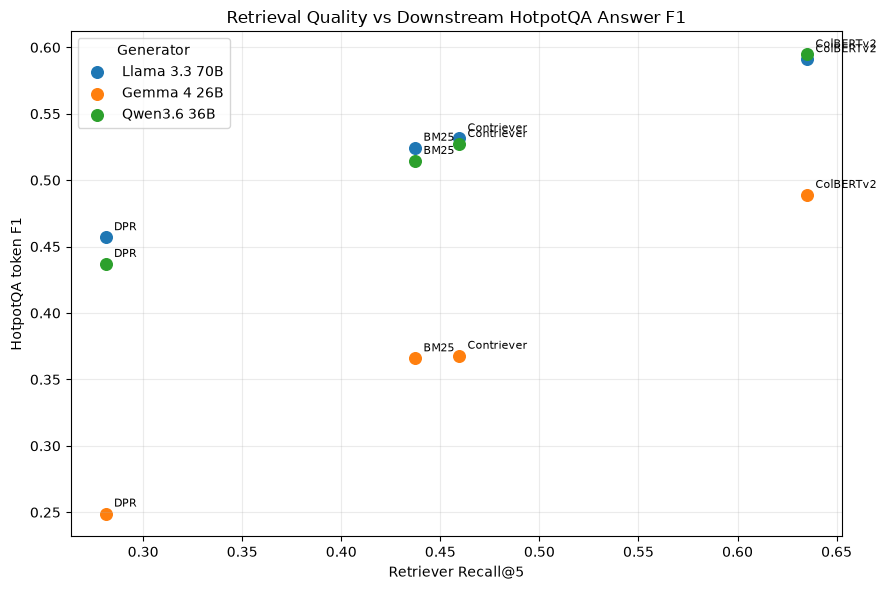

Retrieval-to-answer summary: PASS
LLM/API calls made by this cell: 0


In [13]:
answer_f1 = (
    correctness_summary[
        correctness_summary["condition"] != "WITHOUT CONTEXT"
    ]
    [
        [
            "generator",
            "condition",
            "Measured_N",
            "Token_F1",
        ]
    ]
    .rename(
        columns={
            "generator": "Generator",
            "condition": "Retriever",
            "Measured_N": "Generation Measured N",
            "Token_F1": "Answer F1",
        }
    )
)


retrieval_answer_summary = answer_f1.merge(
    retrieval_summary[
        [
            "Retriever",
            "Measured_N",
            "Recall_at_5",
        ]
    ].rename(
        columns={
            "Measured_N": "Retrieval Measured N",
            "Recall_at_5": "Recall@5",
        }
    ),
    on="Retriever",
    how="left",
    validate="many_to_one",
)


display(
    retrieval_answer_summary.style.format(
        {
            "Recall@5": "{:.3f}",
            "Answer F1": "{:.3f}",
        }
    )
)


fig, ax = plt.subplots(figsize=(9, 6))

for generator in GENERATOR_ORDER:
    subset = retrieval_answer_summary[
        retrieval_answer_summary["Generator"] == generator
    ]

    ax.scatter(
        subset["Recall@5"],
        subset["Answer F1"],
        s=70,
        label=generator,
    )

    for _, row in subset.iterrows():
        ax.annotate(
            row["Retriever"],
            (
                row["Recall@5"],
                row["Answer F1"],
            ),
            xytext=(6, 5),
            textcoords="offset points",
            fontsize=8,
        )

ax.set_xlabel("Retriever Recall@5")
ax.set_ylabel("HotpotQA token F1")
ax.set_title("Retrieval Quality vs Downstream HotpotQA Answer F1")
ax.legend(title="Generator")
ax.grid(alpha=0.25)

fig.tight_layout()
plt.show()

print("Retrieval-to-answer summary: PASS")
print("LLM/API calls made by this cell: 0")

## Question-Type and Difficulty Diagnostics

HotpotQA contains different reasoning structures and difficulty levels.

These diagnostics help determine whether context effects differ between:

- bridge questions
- comparison questions
- difficulty levels

The primary metrics remain overall Exact Match and token F1.

In [14]:
diagnostic_summary = (
    generation_scored
    .groupby(
        [
            "generator",
            "condition",
            "question_type",
            "level",
        ],
        as_index=False,
        observed=True,
    )
    .agg(
        Measured_N=("token_f1", "count"),
        Exact_Match=("exact_match", "mean"),
        Token_F1=("token_f1", "mean"),
    )
)


print("Question-type / difficulty diagnostic: PASS")

display(
    diagnostic_summary.style.format(
        {
            "Exact_Match": "{:.3f}",
            "Token_F1": "{:.3f}",
        }
    )
)

Question-type / difficulty diagnostic: PASS


,generator,condition,question_type,level,Measured_N,Exact_Match,Token_F1
0,Gemma 4 26B,BM25,bridge,hard,5904,0.233,0.331
1,Gemma 4 26B,BM25,comparison,hard,1480,0.444,0.507
2,Gemma 4 26B,ColBERTv2,bridge,hard,5897,0.319,0.447
3,Gemma 4 26B,ColBERTv2,comparison,hard,1481,0.570,0.656
4,Gemma 4 26B,Contriever,bridge,hard,5902,0.237,0.340
5,Gemma 4 26B,Contriever,comparison,hard,1481,0.419,0.479
6,Gemma 4 26B,DPR,bridge,hard,5909,0.171,0.247
7,Gemma 4 26B,DPR,comparison,hard,1487,0.230,0.257
8,Gemma 4 26B,WITHOUT CONTEXT,bridge,hard,5535,0.163,0.270
9,Gemma 4 26B,WITHOUT CONTEXT,comparison,hard,1433,0.595,0.670


## Metric Coverage in This Baseline

| Evaluation area | Status |
|---|---|
| Retrieval effectiveness | **Complete for relevance Top-5** |
| Generation integrity | **Complete** |
| Exact Match | **Complete** |
| Token F1 | **Complete** |
| ROUGE-L | **Complete** |
| WITH vs WITHOUT context | **Complete** |
| Question-type diagnostics | **Complete** |
| Faithfulness / hallucination | Evaluated later |
| Retrieval diversity | Evaluated with diversification |
| Output diversity / answer change | Evaluated later |
| Diversity–accuracy trade-off | Requires Sprint 2 |
| Diversity–hallucination relationship | Requires Sprint 2 |

The saved baseline outputs are reused later. No baseline generation is rerun.

## Main Findings

Execute the notebook from top to bottom before interpreting the numerical
results.

The baseline analysis is designed to establish:

1. which relevance-only retriever gives the strongest HotpotQA evidence;
2. which physical generator performs best;
3. whether adding context improves or degrades EM/F1;
4. whether retrieval quality and answer quality move together;
5. which patterns should be tested again after diversification.

The scientific question for the next stage remains:

> **Does deliberately diversifying retrieved context improve LLM reasoning,
> or does it introduce noise and hallucinations?**

In [15]:
# Compact automatically derived baseline summary

best_rows = (
    correctness_summary
    .sort_values(
        "Token_F1",
        ascending=False,
    )
    .head(5)
    [
        [
            "generator",
            "condition",
            "Token_F1",
            "Exact_Match",
        ]
    ]
)

print("Top five baseline conditions by token F1:")
display(
    best_rows.style.format(
        {
            "Token_F1": "{:.3f}",
            "Exact_Match": "{:.3f}",
        }
    )
)


largest_improvements = (
    context_effects
    .sort_values(
        "F1 Effect",
        ascending=False,
    )
    .head(5)
)

print()
print("Largest WITH_CONTEXT - WITHOUT_CONTEXT F1 effects:")

display(
    largest_improvements[
        [
            "Generator",
            "Retriever",
            "Paired N",
            "F1 Effect",
            "F1 CI lower",
            "F1 CI upper",
        ]
    ].style.format(
        {
            "F1 Effect": "{:+.3f}",
            "F1 CI lower": "{:+.3f}",
            "F1 CI upper": "{:+.3f}",
        }
    )
)

Top five baseline conditions by token F1:


,generator,condition,Token_F1,Exact_Match
14,Qwen3.6 36B,ColBERTv2,0.595,0.458
4,Llama 3.3 70B,ColBERTv2,0.591,0.453
3,Llama 3.3 70B,Contriever,0.532,0.404
13,Qwen3.6 36B,Contriever,0.527,0.399
1,Llama 3.3 70B,BM25,0.524,0.399



Largest WITH_CONTEXT - WITHOUT_CONTEXT F1 effects:


,Generator,Retriever,Paired N,F1 Effect,F1 CI lower,F1 CI upper
11,Qwen3.6 36B,ColBERTv2,6923,+0.224,+0.213,+0.234
3,Llama 3.3 70B,ColBERTv2,7142,+0.177,+0.167,+0.187
10,Qwen3.6 36B,Contriever,6906,+0.156,+0.146,+0.167
8,Qwen3.6 36B,BM25,6915,+0.145,+0.134,+0.155
7,Gemma 4 26B,ColBERTv2,6950,+0.145,+0.133,+0.156


## Reproducibility Audit

The notebook must finish with all baseline integrity checks passing.

No retrieval or LLM generation is executed by this notebook.

In [16]:
audit_checks = []


def add_check(name, condition):
    condition = bool(condition)

    audit_checks.append(
        {
            "Check": name,
            "Status": "PASS" if condition else "FAIL",
        }
    )

    if not condition:
        raise AssertionError(
            f"Notebook audit failed: {name}"
        )


add_check(
    "Official evaluation questions = 7,405",
    len(gold_df) == 7405,
)

add_check(
    "Manifest IDs are unique",
    len(set(manifest_ids)) == 7405,
)

add_check(
    "Gold IDs exactly match manifest IDs",
    set(manifest_ids) == set(gold_by_id),
)

add_check(
    "Generation artifacts = 111,075",
    len(generation_df) == 111075,
)

add_check(
    "15 generator/context conditions",
    len(cell_counts) == 15,
)

add_check(
    "Every condition has 7,405 cells",
    bool((cell_counts == 7405).all()),
)

add_check(
    "Three physical generators",
    set(generation_df["physical_model_id"])
    == {
        "llama-3.3-70b",
        "gemma4-26b",
        "qwen3.6-36b",
    },
)

add_check(
    "Generation ERROR artifacts = 0",
    int(status_totals.get("ERROR", 0)) == 0,
)

add_check(
    "Explicit upstream missing cells = 18",
    int(
        status_totals.get(
            "UPSTREAM_CONTEXT_MISSING",
            0,
        )
    )
    == 18,
)

add_check(
    "15 correctness summary rows",
    len(correctness_summary) == 15,
)

add_check(
    "12 paired context comparisons",
    len(context_effects) == 12,
)

add_check(
    "Four retrieval conditions",
    len(retrieval_summary) == 4,
)


audit_table = pd.DataFrame(audit_checks)

print("FINAL HOTPOTQA NOTEBOOK AUDIT")
print()

display(audit_table)

print()
print("All required baseline checks: PASS")
print("Saved experimental artifacts were reused.")
print("No retrieval or LLM generation was rerun.")
print("LLM/API calls made by this notebook: 0")

FINAL HOTPOTQA NOTEBOOK AUDIT



,Check,Status
0,"Official evaluation questions = 7,405",PASS
1,Manifest IDs are unique,PASS
2,Gold IDs exactly match manifest IDs,PASS
3,"Generation artifacts = 111,075",PASS
4,15 generator/context conditions,PASS
5,"Every condition has 7,405 cells",PASS
6,Three physical generators,PASS
7,Generation ERROR artifacts = 0,PASS
8,Explicit upstream missing cells = 18,PASS
9,15 correctness summary rows,PASS



All required baseline checks: PASS
Saved experimental artifacts were reused.
No retrieval or LLM generation was rerun.
LLM/API calls made by this notebook: 0


## Limitations and Next Steps

This notebook establishes the **non-diversified HotpotQA baseline**.

### Limitations

- `PARSE_FAILURE` and `TRUNCATED` generations are retained but are not
  assigned artificial correctness scores.
- Six Contriever queries contain an upstream empty passage body, producing
  18 explicit missing generator cells across the three LLMs.
- Faithfulness, hallucination, retrieval diversity, and output diversity are
  not yet evaluated here.
- Retrieval-quality versus answer-quality plots are descriptive rather than
  causal.
- Diversification results are not included in this baseline notebook.

### Next steps

After the diversification protocol is confirmed, the saved Top-20 candidate
pools can be reused for:

- MMR
- K-Means
- Agglomerative clustering
- DPP

Each method selects a diversified Top-5, which is then evaluated against the
same relevance-only baseline and WITHOUT_CONTEXT control.

The later analysis will measure:

1. retrieval effectiveness;
2. retrieval diversity;
3. answer correctness;
4. faithfulness / hallucination;
5. output diversity / answer change;
6. diversity–accuracy trade-off;
7. diversity–hallucination relationship.